In [1]:
import torch
import torch.nn as nn
import torchsde
import matplotlib.pyplot as plt
import numpy as np
import os
from dotenv import load_dotenv; load_dotenv()
%cd {os.getenv('PROJECT_PATH')}

from control.model import LinearControlSDE
from control.contoller import OptimalRoute

/home/id94ebid/projects/neuroscience


In [2]:
N = 10
N_controls = 2
dt = 1e-3
h = 1/N
T=1
c = 1.

diag_main = torch.diag_embed(torch.full((N - 1,), -2.0), offset=0)
diag_super = torch.diag_embed(torch.ones(N - 2), offset=1)
A = c/h**2*(diag_main + diag_super + diag_super.T)

b = torch.zeros((N-1,N_controls)); b[0,0]=1.; b[-1,-1]=1
B = c/h**2*(b)

In [3]:
class ConstantControl(nn.Module):
    def __init__(self, B, cte: list[float]):
        super().__init__()
        self.cte = torch.tensor(np.random.choice(cte, B.shape[1])).to(dtype=torch.float32)

    def forward(self, t, y):
        bs = y.shape[0]
        return self.cte.unsqueeze(0).repeat(bs, 1)
    
class SinusoidalControl(nn.Module):
    def __init__(self, B, bs: int):
        super().__init__()
        self.m = B.shape[1]
        self.bs = bs
        self.phase = 2*np.pi*torch.rand((self.bs, self.m))
        self.omega = 2 + 10*torch.rand((self.bs, self.m))

    def forward(self, t, y):
        #print(torch.sin(self.omega*t+self.phase).shape)
        return torch.sin(self.omega*t+self.phase)

# Train Set

In [4]:
torch.manual_seed(1234)

# Initial condition: [position, velocity]
num_trajectories = 3

# Time span
t_span = [0.0, T]
ts = torch.linspace(t_span[0], t_span[1], 100)
n_cte_controls = 100

# Initialize spring-mass-damper system
y0 = [2*torch.rand((num_trajectories,N-1)) for i in range(n_cte_controls)]
controls = [ConstantControl(B, [-1,0,1]) for _ in range(n_cte_controls)]
sdes = [LinearControlSDE(A, B, control_input=c_i, sigma=0.0) for c_i in controls]
ys = [torchsde.sdeint(sde_i, y0_i, ts, method="euler", dt=dt) for sde_i, y0_i in zip(sdes, y0)]

In [5]:
y_total = torch.concatenate(ys, dim=1)
u_total = torch.concatenate([c_i(ts, y_total).unsqueeze(1).repeat(1,num_trajectories,1) for c_i in controls], dim=1)
print(y_total.shape)
print(u_total.shape)
print(ts.shape)
np.savez("data_processed/control/train_laplace.npz", y=y_total.numpy(), u=u_total.numpy(), t=ts.numpy())

torch.Size([100, 300, 9])
torch.Size([100, 300, 2])
torch.Size([100])


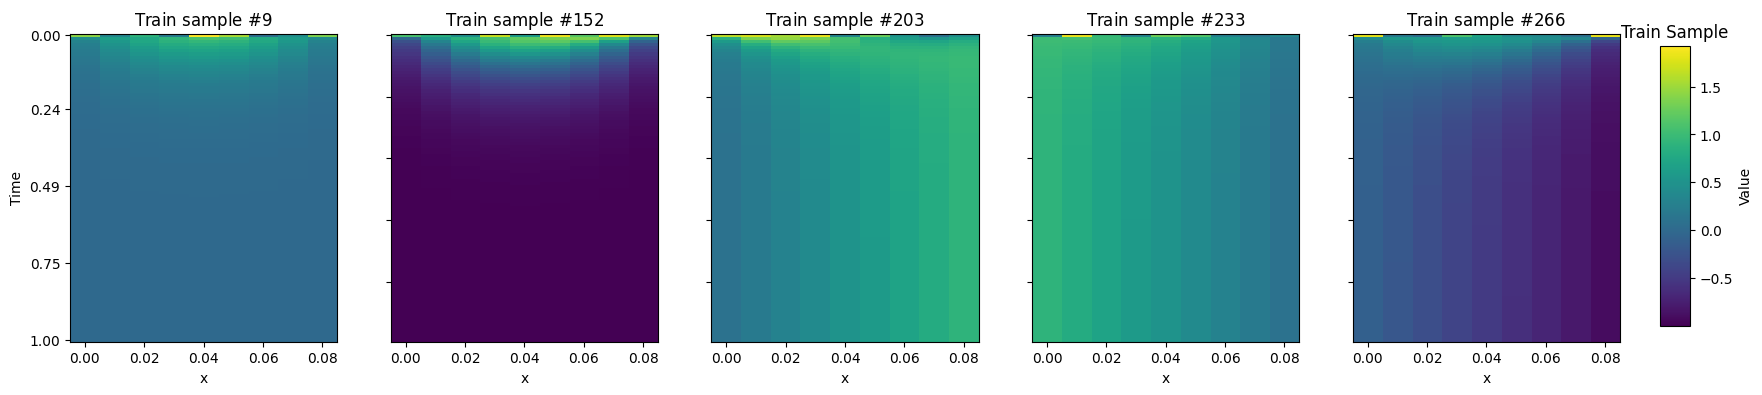

In [6]:
ts_np = ts.detach().numpy()
ys_np = y_total.detach().numpy()

np.random.seed(42)
random_indices = np.random.choice(y_total.shape[1], size=5, replace=False)
random_indices.sort()

num_plots = 5
fig, axes = plt.subplots(1, num_plots, figsize=(20, 4))

# Determine global min/max for consistent colormapping
# This is crucial for comparing the different timesteps
v_min = ys_np[:, random_indices, :].min()
v_max = ys_np[:, random_indices, :].max()

# Plot each matrix
for i, t_index in enumerate(random_indices):
    matrix = ys_np[:, t_index, :]
    # Use vmin and vmax for consistent colormapping
    im = axes[i].imshow(matrix, cmap='viridis', vmin=v_min, vmax=v_max, aspect='auto')
    axes[i].set_title(f'Train sample #${t_index}$')
    axes[i].set_xlabel("x")
    axes[i].set_yticklabels([])
    tick_indices = np.linspace(0, ys_np.shape[-1]-1, 5, dtype=int)
    axes[i].set_xticks(tick_indices)
    axes[i].set_xticklabels([f'{ts_np[idx]:.2f}' for idx in tick_indices])

tick_indices = np.linspace(0, len(ts_np) - 1, 5, dtype=int)
axes[0].set_yticks(tick_indices)
axes[0].set_yticklabels([f'{ts_np[idx]:.2f}' for idx in tick_indices])

axes[0].set_ylabel("Time")
# Add a single colorbar for all plots
cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
fig.colorbar(im, cax=cbar_ax, label='Value')

plt.title('Train Sample')
plt.savefig('images/laplace_train.png', dpi=300, bbox_inches='tight')
plt.show()

# Test set

In [7]:
torch.manual_seed(1234)

# Initial condition: [position, velocity]
num_trajectories = 256

# Initialize spring-mass-damper system
y0 = 2*torch.rand((num_trajectories,N-1))
control = SinusoidalControl(B, num_trajectories) 
sde = LinearControlSDE(A, B, control_input=control, sigma=0.0) 
ys = torchsde.sdeint(sde, y0, ts, method="euler", dt=dt)

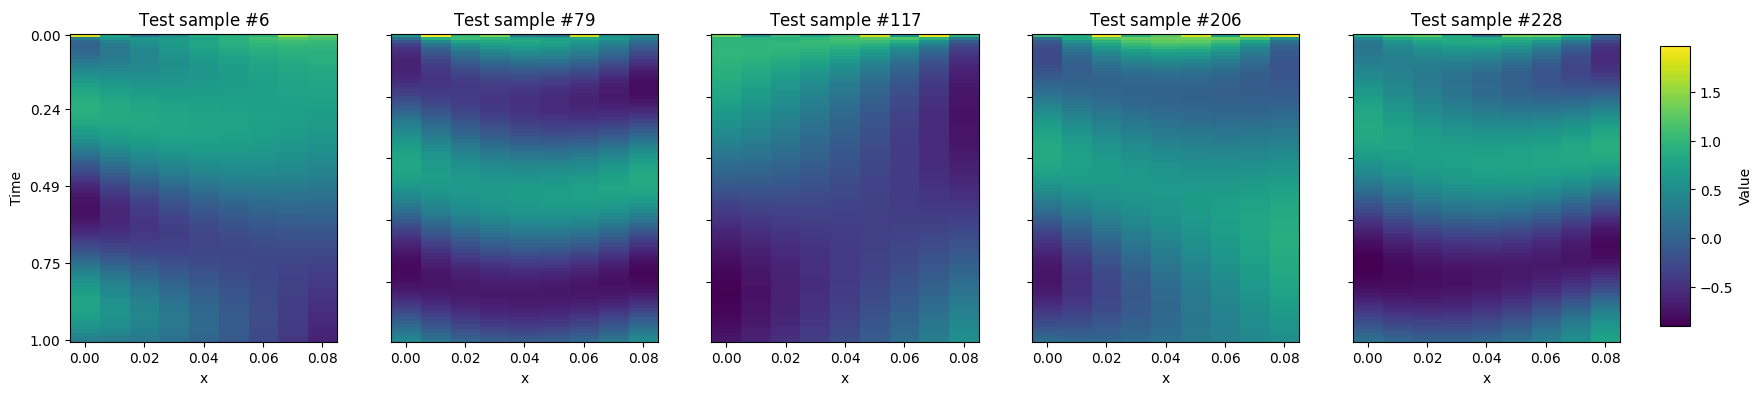

In [8]:
ts_np = ts.detach().numpy()
ys_np = ys.detach().numpy()

np.random.seed(42)
random_indices = np.random.choice(ys.shape[1], size=5, replace=False)
random_indices.sort()

num_plots = 5
fig, axes = plt.subplots(1, num_plots, figsize=(20, 4))

# Determine global min/max for consistent colormapping
# This is crucial for comparing the different timesteps
v_min = ys_np[:, random_indices, :].min()
v_max = ys_np[:, random_indices, :].max()

# Plot each matrix
for i, t_index in enumerate(random_indices):
    matrix = ys_np[:, t_index, :]
    # Use vmin and vmax for consistent colormapping
    im = axes[i].imshow(matrix, cmap='viridis', vmin=v_min, vmax=v_max, aspect='auto')
    axes[i].set_title(f'Test sample #${t_index}$')
    axes[i].set_xlabel("x")
    axes[i].set_yticklabels([])
    tick_indices = np.linspace(0, ys_np.shape[-1]-1, 5, dtype=int)
    axes[i].set_xticks(tick_indices)
    axes[i].set_xticklabels([f'{ts_np[idx]:.2f}' for idx in tick_indices])

tick_indices = np.linspace(0, len(ts_np) - 1, 5, dtype=int)
axes[0].set_yticks(tick_indices)
axes[0].set_yticklabels([f'{ts_np[idx]:.2f}' for idx in tick_indices])

axes[0].set_ylabel("Time")
# Add a single colorbar for all plots
cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
fig.colorbar(im, cax=cbar_ax, label='Value')

plt.savefig('images/laplace_test.png', dpi=300, bbox_inches='tight')
plt.show()

In [9]:
y_total = ys
u_total = control(ts[:, None, None], None)
print(y_total.shape)
print(u_total.shape)
print(ts.shape)
np.savez("data_processed/control/test_laplace.npz", y=y_total.numpy(), u=u_total.numpy(), t=ts.numpy())

torch.Size([100, 256, 9])
torch.Size([100, 256, 2])
torch.Size([100])
